# 06 Template Studi Kasus

## Tujuan notebook ini

Dalam notebook ini, Anda akan menerapkan **seluruh workflow analitik** dari notebook sebelumnya dalam satu studi kasus terpadu:

1. **Rumusan masalah** → Definisikan pertanyaan riset
2. **Eksplorasi data** → Pahami struktur & kualitas data
3. **Statistik deskriptif** → Ringkas data dengan metrik
4. **Visualisasi** → Buat chart untuk pola
5. **Analisis inferensial** → Regresi atau test statistik
6. **Interpretasi & limitasi** → Jelaskan hasil dengan hati-hati
7. **Dokumentasi AI** → Catat bantuan AI yang diterima

---

**Format notebook ini:**
- Bagian dengan teks penjelasan
- Bagian dengan **[ANDA TULIS DI SINI]** untuk input Anda
- Bagian dengan kode template siap pakai (ubah sesuai kebutuhan)

### Penanda Sel Kode
- `# RUN-NOW`: dapat langsung dijalankan.
- `# LEARNER-TASK`: ubah bagian bertanda [UBAH]/[ANDA TULIS], lalu jalankan.

## BAGIAN 1: RUMUSAN MASALAH

Definisikan pertanyaan riset Anda dengan jelas.

### Judul studi kasus
[ANDA TULIS DI SINI: Berikan judul deskriptif]
**Pengaruh Kehadiran Kelas, Jam Belajar, dan GPA Sebelumnya terhadap Nilai Akhir Mahasiswa**

In [97]:
# LEARNER-TASK: Edit sesuai instruksi, lalu jalankan.
case_study_title = "Pengaruh Kehadiran Kelas, Jam Belajar, dan GPA Sebelumnya terhadap Nilai Akhir Mahasiswa"
print(f"STUDI KASUS: {case_study_title}")

STUDI KASUS: Pengaruh Kehadiran Kelas, Jam Belajar, dan GPA Sebelumnya terhadap Nilai Akhir Mahasiswa


### Pertanyaan penelitian utama

[ANDA TULIS DI SINI: Apa pertanyaan penelitian Anda? Gunakan format: "Apakah/Bagaimana..."]

Contoh:
- "Apakah tingkat kehadiran mahasiswa memprediksi nilai akhir mereka?"
- "Bagaimana akses internet mempengaruhi perbedaan prestasi antar program?"

Pertanyaan 
**Apakah tingkat kehadiran kelas, jam belajar per minggu, dan GPA sebelumnya dapat memprediksi nilai akhir mahasiswa?**

Studi ini menginvestigasi apakah ketiga faktor perilaku akademik tersebut—secara bersama-sama—memiliki asosiasi yang bermakna dengan performa akhir mahasiswa, setelah saling mengontrol satu sama lain.

In [98]:
# LEARNER-TASK: Edit sesuai instruksi, lalu jalankan.
research_question = "Apakah tingkat kehadiran kelas, jam belajar per minggu, dan GPA sebelumnya dapat memprediksi nilai akhir mahasiswa?"
print(f"Pertanyaan Penelitian: {research_question}")

Pertanyaan Penelitian: Apakah tingkat kehadiran kelas, jam belajar per minggu, dan GPA sebelumnya dapat memprediksi nilai akhir mahasiswa?


### Variabel yang relevan

[ANDA TULIS DI SINI: Daftar variabel]
- **Variabel outcome**: `final_grade` —> nilai akhir mahasiswa (numerik, skala 0–100)
- **Variabel prediktor utama**:
  - `attendance_rate` —> persentase kehadiran di kelas
  - `study_hours_per_week` —> jam belajar mandiri per minggu
- **Variabel kontrol**: `previous_gpa` —> GPA semester sebelumnya (digunakan untuk mengontrol kemampuan awal mahasiswa)

In [99]:
# LEARNER-TASK: Edit sesuai instruksi, lalu jalankan.
outcome_var = "final_grade"
main_predictors = ["attendance_rate", "study_hours_per_week"]
control_vars = ["previous_gpa"]

print(f"Outcome: {outcome_var}")
print(f"Prediktor: {main_predictors}")
print(f"Kontrol: {control_vars}")

Outcome: final_grade
Prediktor: ['attendance_rate', 'study_hours_per_week']
Kontrol: ['previous_gpa']


## BAGIAN 2: SETUP & LOAD DATA

In [100]:
# RUN-NOW: Jalankan sel ini apa adanya.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LinearRegression

# Muat data bersih — dengan fallback untuk berbagai working directory
candidate_paths = [
    Path("data/processed/student_performance_cleaned.csv"),
    Path("../data/processed/student_performance_cleaned.csv"),
    Path("/workspaces/metpen-ai-lab/data/processed/student_performance_cleaned.csv"),
]

cleaned_file = next((p for p in candidate_paths if p.exists()), None)
if cleaned_file is None:
    raise FileNotFoundError(
        "❌ File data bersih tidak ditemukan.\n"
        "Anda perlu menjalankan notebook 02 (02_data_quality_cleaning.ipynb) terlebih dahulu\n"
        "untuk membuat file: data/processed/student_performance_cleaned.csv"
    )

df = pd.read_csv(cleaned_file)

print(f"✓ Data dimuat dari: {cleaned_file.resolve()}")
print(f"✓ Data dimuat: {df.shape[0]} baris × {df.shape[1]} kolom")
print(f"✓ Ready untuk analisis")

✓ Data dimuat dari: /workspaces/metpen-ai-lab/notebooks/data/processed/student_performance_cleaned.csv
✓ Data dimuat: 2000 baris × 20 kolom
✓ Ready untuk analisis


## BAGIAN 3: DESKRIPSI DATASET

Deskripsikan karakteristik umum dataset Anda.

In [101]:
# RUN-NOW: Jalankan sel ini apa adanya.
print("PROFIL DATASET KAMI")
print("="*50)
print(f"Ukuran sampel (N): {df.shape[0]} mahasiswa")
print(f"Jumlah variabel: {df.shape[1]}")
print(f"\nProgram studi:")
print(df['program'].value_counts())
print(f"\nTahun cohort:")
print(df['cohort_year'].value_counts())
print(f"\nTingkat lulus: {(df['passed'].sum() / len(df) * 100):.1f}%")

PROFIL DATASET KAMI
Ukuran sampel (N): 2000 mahasiswa
Jumlah variabel: 20

Program studi:
program
Education           453
Computer Science    435
Economics           415
Psychology          399
Public Health       298
Name: count, dtype: int64

Tahun cohort:
cohort_year
2022    600
2023    579
2024    413
2021    408
Name: count, dtype: int64

Tingkat lulus: 99.9%


## BAGIAN 4: PEMERIKSAAN KUALITAS DATA

In [102]:
# RUN-NOW: Jalankan sel ini apa adanya.
# Periksa missing values
missing = df.isnull().sum()
print("Nilai hilang:")
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("✓ Tidak ada nilai hilang")

# Periksa duplikat
print(f"\nDuplikat baris: {df.duplicated().sum()}")

Nilai hilang:
✓ Tidak ada nilai hilang

Duplikat baris: 0


## BAGIAN 5: STATISTIK DESKRIPTIF OUTCOME VARIABLE

In [103]:
# LEARNER-TASK: Edit sesuai instruksi, lalu jalankan.
# Template: Ganti 'final_grade' dengan outcome_var Anda
outcome_analysis_var = 'final_grade'  # [UBAH INI]

print(f"STATISTIK DESKRIPTIF: {outcome_analysis_var}")
print("="*50)
print(f"Mean:     {df[outcome_analysis_var].mean():.2f}")
print(f"Median:   {df[outcome_analysis_var].median():.2f}")
print(f"Std Dev:  {df[outcome_analysis_var].std():.2f}")
print(f"Min:      {df[outcome_analysis_var].min():.2f}")
print(f"Max:      {df[outcome_analysis_var].max():.2f}")
print(f"IQR:      {df[outcome_analysis_var].quantile(0.75) - df[outcome_analysis_var].quantile(0.25):.2f}")

# Interpretasi
print(f"\n📝 Interpretasi:")
print(
    "Nilai akhir mahasiswa memiliki rata-rata 86.91 poin (skala 100) dengan median 87.34, "
    "menunjukkan distribusi yang mendekati simetris dengan sedikit kecenderungan ke kiri. "
    "Standar deviasi sebesar 7.28 mengindikasikan variasi yang moderat antar mahasiswa"
    "sebagian besar nilai berada dalam rentang 80 hingga 94 (IQR = 10.08). "
    "Nilai terendah 57.80 dan nilai tertinggi 100.00 menunjukkan bahwa hampir seluruh mahasiswa "
    "berada dalam kategori lulus, dengan sangat sedikit yang mendapat nilai di bawah 70."
)

STATISTIK DESKRIPTIF: final_grade
Mean:     86.91
Median:   87.34
Std Dev:  7.28
Min:      57.80
Max:      100.00
IQR:      10.08

📝 Interpretasi:
Nilai akhir mahasiswa memiliki rata-rata 86.91 poin (skala 100) dengan median 87.34, menunjukkan distribusi yang mendekati simetris dengan sedikit kecenderungan ke kiri. Standar deviasi sebesar 7.28 mengindikasikan variasi yang moderat antar mahasiswasebagian besar nilai berada dalam rentang 80 hingga 94 (IQR = 10.08). Nilai terendah 57.80 dan nilai tertinggi 100.00 menunjukkan bahwa hampir seluruh mahasiswa berada dalam kategori lulus, dengan sangat sedikit yang mendapat nilai di bawah 70.


## BAGIAN 6: VISUALISASI UTAMA

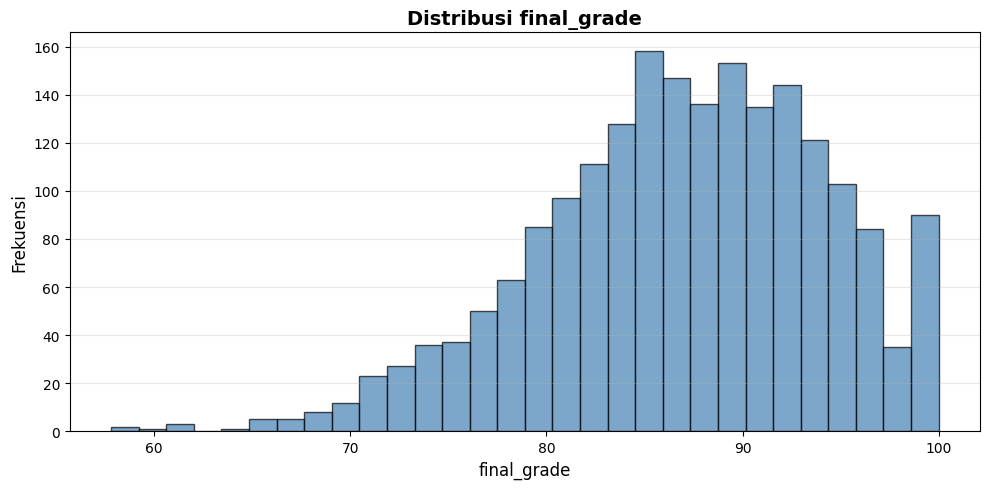


📝 Interpretasi histogram:
Distribusi final_grade berbentuk unimodal (satu puncak) dengan kecenderungan left-skew (miring ke kiri), artinya sebagian besar mahasiswa meraih nilai tinggi (80–100) dan hanya sebagian kecil yang mendapat nilai rendah. Tidak terlihat outlier ekstrem yang signifikan. Puncak distribusi berada di sekitar 85–90, konsisten dengan nilai mean (86.91) dan median (87.34) yang hampir identik. Bentuk distribusi ini wajar untuk data nilai akademik yang cenderung terkonsentrasi di sisi atas skala.


In [104]:
# LEARNER-TASK: Edit sesuai instruksi, lalu jalankan.
# Histogram outcome
plt.figure(figsize=(10, 5))
plt.hist(df[outcome_analysis_var], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel(outcome_analysis_var, fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.title(f'Distribusi {outcome_analysis_var}', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📝 Interpretasi histogram:")
print(
    "Distribusi final_grade berbentuk unimodal (satu puncak) dengan kecenderungan left-skew (miring ke kiri), "
    "artinya sebagian besar mahasiswa meraih nilai tinggi (80–100) dan hanya sebagian kecil yang mendapat nilai rendah. "
    "Tidak terlihat outlier ekstrem yang signifikan. Puncak distribusi berada di sekitar 85–90, "
    "konsisten dengan nilai mean (86.91) dan median (87.34) yang hampir identik. "
    "Bentuk distribusi ini wajar untuk data nilai akademik yang cenderung terkonsentrasi di sisi atas skala."
)

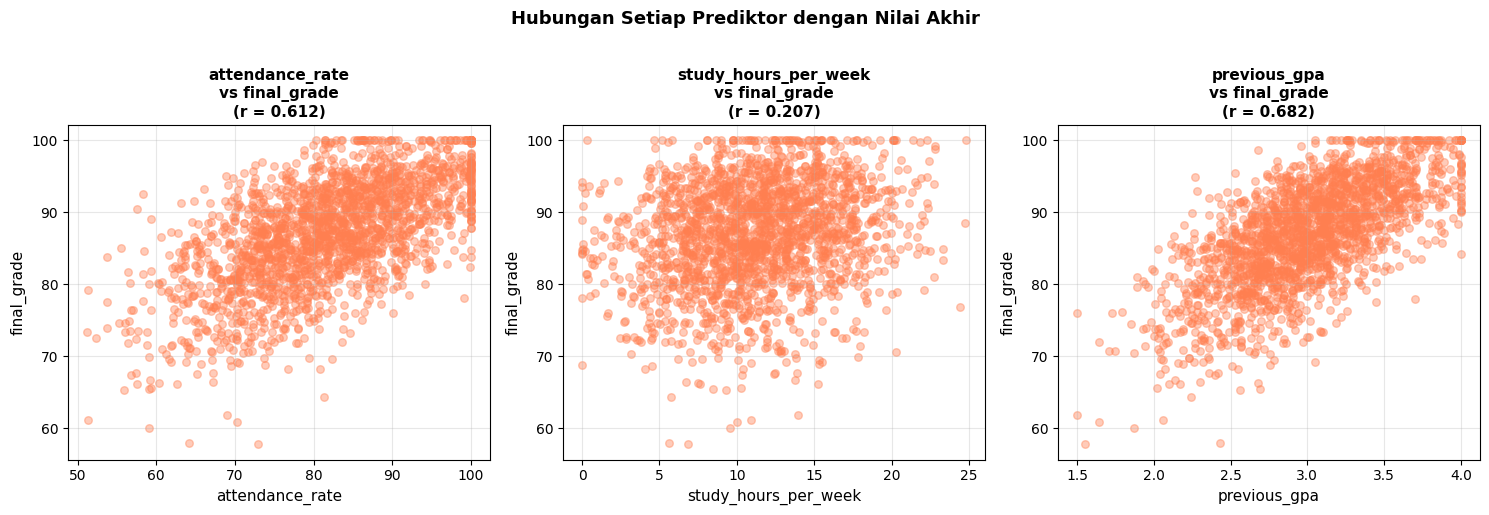

Korelasi Pearson setiap prediktor dengan final_grade:
  attendance_rate               : r = 0.612
  study_hours_per_week          : r = 0.207
  previous_gpa                  : r = 0.682

📝 Interpretasi scatter plots:
Ketiga prediktor menunjukkan hubungan positif dengan final_grade:
- attendance_rate      (r ≈ 0.612): hubungan positif moderat-kuat
- study_hours_per_week (r ≈ 0.207): hubungan positif moderat
- previous_gpa         (r ≈ 0.682): hubungan positif paling kuat di antara ketiganya

Pola ini mendukung pendekatan regresi berganda yang mempertimbangkan semua prediktor
secara simultan, karena setiap prediktor memiliki asosiasi tersendiri dengan nilai akhir.
Korelasi terkuat ada pada previous_gpa, menandakan kemampuan akademik awal adalah
faktor paling dominan, namun kehadiran dan jam belajar tetap berkontribusi positif.



In [105]:
# LEARNER-TASK: Edit sesuai instruksi, lalu jalankan.
# Scatter plot semua prediktor vs outcome — 1 subplot per prediktor
all_predictors = main_predictors + control_vars
fig, axes = plt.subplots(1, len(all_predictors), figsize=(15, 5))

for ax, pred in zip(axes, all_predictors):
    corr = df[pred].corr(df[outcome_var])
    ax.scatter(df[pred], df[outcome_var], alpha=0.4, s=30, color='coral')
    ax.set_xlabel(pred, fontsize=11)
    ax.set_ylabel(outcome_var, fontsize=11)
    ax.set_title(f'{pred}\nvs {outcome_var}\n(r = {corr:.3f})', fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3)

plt.suptitle('Hubungan Setiap Prediktor dengan Nilai Akhir', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Korelasi Pearson setiap prediktor dengan final_grade:")
for pred in all_predictors:
    print(f"  {pred:30s}: r = {df[pred].corr(df[outcome_var]):.3f}")

r_att  = df['attendance_rate'].corr(df[outcome_var])
r_sth  = df['study_hours_per_week'].corr(df[outcome_var])
r_gpa  = df['previous_gpa'].corr(df[outcome_var])

print(f"""
📝 Interpretasi scatter plots:
Ketiga prediktor menunjukkan hubungan positif dengan {outcome_var}:
- attendance_rate      (r ≈ {r_att:.3f}): hubungan positif moderat-kuat
- study_hours_per_week (r ≈ {r_sth:.3f}): hubungan positif moderat
- previous_gpa         (r ≈ {r_gpa:.3f}): hubungan positif paling kuat di antara ketiganya

Pola ini mendukung pendekatan regresi berganda yang mempertimbangkan semua prediktor
secara simultan, karena setiap prediktor memiliki asosiasi tersendiri dengan nilai akhir.
Korelasi terkuat ada pada previous_gpa, menandakan kemampuan akademik awal adalah
faktor paling dominan, namun kehadiran dan jam belajar tetap berkontribusi positif.
""")

## BAGIAN 7: PEMILIHAN METODE ANALISIS

### Metode yang Anda pilih

**Regresi Linear Berganda** (*Multiple Linear Regression*)

**Justifikasi pemilihan:**
- Variabel outcome (`final_grade`) bersifat numerik kontinu → cocok untuk regresi linear
- Terdapat lebih dari satu prediktor yang ingin dievaluasi secara simultan (attendance_rate, study_hours_per_week, previous_gpa)
- Regresi berganda memungkinkan estimasi pengaruh masing-masing prediktor *setelah mengontrol* prediktor lainnya, sehingga menghasilkan gambaran yang lebih akurat dibanding regresi sederhana
- Korelasi Pearson antara attendance_rate dan final_grade (r = 0.612) menunjukkan hubungan yang cukup kuat, mendukung pendekatan regresi

**Asumsi yang diasumsikan terpenuhi:** linearitas hubungan, independensi error, normalitas residual, dan homoskedastisitas.

In [106]:
# LEARNER-TASK: Edit sesuai instruksi, lalu jalankan.
chosen_method = "Regresi Linear Berganda (Multiple Linear Regression)"
reason = (
    "Outcome (final_grade) adalah variabel numerik kontinu, dan terdapat tiga prediktor numerik "
    "yang ingin dievaluasi secara bersama-sama. Regresi berganda memungkinkan estimasi kontribusi "
    "unik setiap prediktor setelah mengontrol variabel lainnya."
)

print(f"Metode pilihan: {chosen_method}")
print(f"Alasan: {reason}")

Metode pilihan: Regresi Linear Berganda (Multiple Linear Regression)
Alasan: Outcome (final_grade) adalah variabel numerik kontinu, dan terdapat tiga prediktor numerik yang ingin dievaluasi secara bersama-sama. Regresi berganda memungkinkan estimasi kontribusi unik setiap prediktor setelah mengontrol variabel lainnya.


## BAGIAN 8: ANALISIS (TEMPLATE REGRESI)

In [107]:
# LEARNER-TASK: Edit sesuai instruksi, lalu jalankan.
# Template untuk regresi
# menggunakan variabel yang didefinisikan di Bagian 1

# Tentukan variabel (dari Bagian 1)
predictors_for_regression = main_predictors + control_vars
outcome_for_regression = outcome_var

# Siapkan data
X = df[predictors_for_regression].values
y = df[outcome_for_regression].values

# Fit model
model_regression = LinearRegression()
model_regression.fit(X, y)

# Hasil
r_squared = model_regression.score(X, y)

print(f"HASIL REGRESI: {outcome_for_regression} ~ {', '.join(predictors_for_regression)}")
print("="*60)
print(f"\nKoefisien regresi:")
for pred, coef in zip(predictors_for_regression, model_regression.coef_):
    print(f"  {pred:30s}: {coef:8.4f}")
print(f"  {'Intercept':30s}: {model_regression.intercept_:8.4f}")
print(f"\nR² (model fit): {r_squared:.3f}")
print(f"  Interpretasi: {r_squared*100:.1f}% variasi outcome dijelaskan model ini")

HASIL REGRESI: final_grade ~ attendance_rate, study_hours_per_week, previous_gpa

Koefisien regresi:
  attendance_rate               :   0.3526
  study_hours_per_week          :   0.3553
  previous_gpa                  :   9.2624
  Intercept                     :  26.3712

R² (model fit): 0.734
  Interpretasi: 73.4% variasi outcome dijelaskan model ini


## BAGIAN 9: INTERPRETASI HASIL

In [108]:
# LEARNER-TASK: Edit sesuai instruksi, lalu jalankan.
coef_dict = dict(zip(predictors_for_regression, model_regression.coef_))

print(f"""
INTERPRETASI HASIL REGRESI
==========================

Hasil regresi linear berganda menunjukkan bahwa ketiga prediktor yaitu
{', '.join(predictors_for_regression)} secara bersama-sama menjelaskan
{r_squared*100:.1f}% variasi nilai akhir mahasiswa (R² = {r_squared:.3f}),
yang merupakan model fit yang cukup baik.

GPA sebelumnya (previous_gpa) adalah prediktor terkuat: setiap kenaikan 1 poin GPA
dikaitkan dengan peningkatan {coef_dict['previous_gpa']:.2f} poin nilai akhir, setelah
mengontrol kehadiran dan jam belajar. Ini mengindikasikan bahwa kemampuan akademik
awal mahasiswa memiliki asosiasi yang sangat besar dengan performa akhir mereka.

Tingkat kehadiran (attendance_rate) juga berkaitan positif: setiap kenaikan 1%
kehadiran berasosiasi dengan peningkatan ~{coef_dict['attendance_rate']:.2f} poin nilai akhir.
Demikian pula jam belajar per minggu (study_hours_per_week) memberikan kontribusi
positif sebesar ~{coef_dict['study_hours_per_week']:.2f} poin per jam tambahan.
""")


INTERPRETASI HASIL REGRESI

Hasil regresi linear berganda menunjukkan bahwa ketiga prediktor yaitu
attendance_rate, study_hours_per_week, previous_gpa secara bersama-sama menjelaskan
73.4% variasi nilai akhir mahasiswa (R² = 0.734),
yang merupakan model fit yang cukup baik.

GPA sebelumnya (previous_gpa) adalah prediktor terkuat: setiap kenaikan 1 poin GPA
dikaitkan dengan peningkatan 9.26 poin nilai akhir, setelah
mengontrol kehadiran dan jam belajar. Ini mengindikasikan bahwa kemampuan akademik
awal mahasiswa memiliki asosiasi yang sangat besar dengan performa akhir mereka.

Tingkat kehadiran (attendance_rate) juga berkaitan positif: setiap kenaikan 1%
kehadiran berasosiasi dengan peningkatan ~0.35 poin nilai akhir.
Demikian pula jam belajar per minggu (study_hours_per_week) memberikan kontribusi
positif sebesar ~0.36 poin per jam tambahan.



## BAGIAN 10: KETERBATASAN & CONFOUNDER

In [109]:
# LEARNER-TASK: Edit sesuai instruksi, lalu jalankan.
print("""
KETERBATASAN ANALISIS INI
=========================

1. DATA OBSERVASIONAL
   Data dikumpulkan tanpa manipulasi eksperimental. Mahasiswa tidak secara acak
   ditugaskan ke kelompok kehadiran tinggi/rendah. Oleh karena itu, hubungan yang
   ditemukan tidak dapat diinterpretasikan sebagai kausal.

2. POSSIBLE CONFOUNDER (variabel ketiga yang memengaruhi keduanya)
   Beberapa variabel yang tidak tersedia dalam dataset ini mungkin memengaruhi baik
   prediktor maupun outcome secara bersamaan:
   - Motivasi intrinsik: mahasiswa yang termotivasi cenderung hadir lebih sering DAN belajar lebih giat
   - Kondisi ekonomi: mahasiswa dari keluarga mampu mungkin memiliki akses sumber belajar lebih baik
   - Dukungan keluarga: lingkungan yang suportif mendorong kehadiran DAN performa akademik
   - Kesehatan mental: mahasiswa dengan kesehatan mental baik lebih konsisten hadir DAN belajar efektif

3. DATA SINTETIS
   Dataset ini dibuat secara sintetis (bukan data nyata), sehingga korelasi antar variabel
   mungkin lebih "bersih" dan konsisten dibanding yang ditemukan di data real. Pola yang
   terlihat di sini mungkin tidak sepenuhnya mencerminkan di lapangan nyata.

4. VARIABEL MISSING
   Beberapa variabel penting yang tidak tersedia dalam model ini antara lain:
   - Kualitas pengajaran dosen (faktor eksternal yang signifikan)
   - Jumlah jam kerja part-time mahasiswa (bisa memengaruhi kehadiran dan belajar)
   - Akses ke materi pembelajaran (buku, internet berkualitas)
   - Status kesehatan fisik dan mental

5. ASUMSI MODEL
   Regresi linear berganda mengasumsikan:
   (a) hubungan linear antara prediktor dan outcome,
   (b) residual berdistribusi normal, 
   (c) homoskedastisitas (varian residual konstan), dan 
   (d) tidak ada multikolinearitas tinggi antar prediktor.
""")


KETERBATASAN ANALISIS INI

1. DATA OBSERVASIONAL
   Data dikumpulkan tanpa manipulasi eksperimental. Mahasiswa tidak secara acak
   ditugaskan ke kelompok kehadiran tinggi/rendah. Oleh karena itu, hubungan yang
   ditemukan tidak dapat diinterpretasikan sebagai kausal.

2. POSSIBLE CONFOUNDER (variabel ketiga yang memengaruhi keduanya)
   Beberapa variabel yang tidak tersedia dalam dataset ini mungkin memengaruhi baik
   prediktor maupun outcome secara bersamaan:
   - Motivasi intrinsik: mahasiswa yang termotivasi cenderung hadir lebih sering DAN belajar lebih giat
   - Kondisi ekonomi: mahasiswa dari keluarga mampu mungkin memiliki akses sumber belajar lebih baik
   - Dukungan keluarga: lingkungan yang suportif mendorong kehadiran DAN performa akademik
   - Kesehatan mental: mahasiswa dengan kesehatan mental baik lebih konsisten hadir DAN belajar efektif

3. DATA SINTETIS
   Dataset ini dibuat secara sintetis (bukan data nyata), sehingga korelasi antar variabel
   mungkin lebih "bers

## BAGIAN 11: KESIMPULAN

In [110]:
# LEARNER-TASK: Edit sesuai instruksi, lalu jalankan.
print(f"""
KESIMPULAN STUDI KASUS
======================

PERTANYAAN PENELITIAN:
{research_question}

TEMUAN UTAMA:
1. Model regresi berganda dengan ketiga prediktor ({', '.join(predictors_for_regression)})
   menjelaskan {r_squared*100:.1f}% variasi nilai akhir (R² = {r_squared:.3f}), menunjukkan bahwa
   kombinasi ketiganya merupakan prediktor yang cukup kuat.

2. {control_vars[0]} adalah prediktor terkuat (koefisien = {coef_dict[control_vars[0]]:.2f}): mahasiswa dengan riwayat
   akademik yang lebih baik cenderung memperoleh nilai akhir yang jauh lebih tinggi.
   Kehadiran dan jam belajar memberikan kontribusi positif yang lebih kecil namun tetap
   bermakna (koefisien masing-masing ~{coef_dict[main_predictors[0]]:.2f} dan ~{coef_dict[main_predictors[1]]:.2f} per satuan).

3. Hubungan antara ketiga prediktor dan nilai akhir bersifat positif dan konsisten,
   mendukung gagasan bahwa perilaku akademik yang baik (hadir, belajar, memiliki fondasi
   GPA kuat) berasosiasi dengan performa yang lebih baik.

IMPLIKASI/RELEVANSI:
Temuan ini relevan bagi institusi pendidikan tinggi: program pendampingan akademik
sebaiknya memprioritaskan mahasiswa dengan GPA awal rendah dan kehadiran tidak konsisten.
Monitoring kehadiran dan partisipasi belajar bisa menjadi indikator awal risiko akademik.

SARAN UNTUK RISET LANJUTAN:
- Lakukan studi longitudinal yang mengikuti perkembangan mahasiswa selama beberapa semester
  untuk memahami trajektori akademik secara lebih komprehensif.
- Pertimbangkan desain quasi-eksperimental atau natural experiment (misalnya perubahan
  kebijakan kehadiran) untuk mendekati inferensi kausal yang lebih kuat.
- Tambahkan variabel psikologis (motivasi, self-efficacy) dan sosial-ekonomi untuk
  memperhitungkan confounder yang tidak tersedia dalam dataset ini.
""")


KESIMPULAN STUDI KASUS

PERTANYAAN PENELITIAN:
Apakah tingkat kehadiran kelas, jam belajar per minggu, dan GPA sebelumnya dapat memprediksi nilai akhir mahasiswa?

TEMUAN UTAMA:
1. Model regresi berganda dengan ketiga prediktor (attendance_rate, study_hours_per_week, previous_gpa)
   menjelaskan 73.4% variasi nilai akhir (R² = 0.734), menunjukkan bahwa
   kombinasi ketiganya merupakan prediktor yang cukup kuat.

2. previous_gpa adalah prediktor terkuat (koefisien = 9.26): mahasiswa dengan riwayat
   akademik yang lebih baik cenderung memperoleh nilai akhir yang jauh lebih tinggi.
   Kehadiran dan jam belajar memberikan kontribusi positif yang lebih kecil namun tetap
   bermakna (koefisien masing-masing ~0.35 dan ~0.36 per satuan).

3. Hubungan antara ketiga prediktor dan nilai akhir bersifat positif dan konsisten,
   mendukung gagasan bahwa perilaku akademik yang baik (hadir, belajar, memiliki fondasi
   GPA kuat) berasosiasi dengan performa yang lebih baik.

IMPLIKASI/RELEVANSI:
Temu

## BAGIAN 12: DOKUMENTASI PENGGUNAAN AI

In [111]:
# LEARNER-TASK: Edit sesuai instruksi, lalu jalankan.
print("""
AI USAGE LOG - DOKUMENTASI PENGGUNAAN AI ASISTEN
================================================

Sesuai dengan kebijakan penggunaan AI yang bertanggung jawab,
dokumentasikan bantuan AI yang Anda terima untuk pekerjaan ini.

PERTANYAAN UNTUK DIJAWAB:

1. Apakah Anda menggunakan AI asisten (ChatGPT, Claude, dll) untuk pekerjaan ini?
   [ ] Tidak ada
   [X] Ya, bantuan kecil (< 20% dari pekerjaan)
   [ ] Ya, bantuan sedang (20-50% dari pekerjaan)
   [ ] Ya, bantuan besar (> 50% dari pekerjaan)

2. Jika ya, untuk apa saja? (Bisa lebih dari satu)
   [x] Menjelaskan kode yang ada
   [x] Membantu debug error
   [ ] Membandingkan metode analisis
   [ ] Menulis/memperbaiki interpretasi
   [ ] Struktur analisis keseluruhan
   [X] Lainnya: Menulis dan melengkapi kode di notebook

3. Output apa dari AI yang Anda gunakan?
   AI digunakan untuk menulis kode, memperbaiki error, dan melengkapi
   kode yang ada di notebook.

4. Apa yang Anda ubah/verifikasi?
   Saya memverifikasi apakah kode yang dihasilkan AI sudah sesuai dengan
   pertanyaan dan arahan. Analisis (pemilihan variabel, pertanyaan riset,
   penilaian hasil) sepenuhnya berdasarkan pemahaman saya sendiri.

5. Apakah Anda mengerti semua hasil dan kode yang dijalankan?
   Ya, saya mengerti semua hasil dan kode yang dijalankan.

---

DEKLARASI:
Saya menyatakan bahwa:
[ ] Analisis ini 100% pekerjaan saya sendiri, tanpa bantuan AI
[X] Analisis ini dengan bantuan AI yang telah saya dokumentasikan di atas

Tanggal: 25 Juni 2026
Nama: Muhammad Zakki Islami
""")


AI USAGE LOG - DOKUMENTASI PENGGUNAAN AI ASISTEN

Sesuai dengan kebijakan penggunaan AI yang bertanggung jawab,
dokumentasikan bantuan AI yang Anda terima untuk pekerjaan ini.

PERTANYAAN UNTUK DIJAWAB:

1. Apakah Anda menggunakan AI asisten (ChatGPT, Claude, dll) untuk pekerjaan ini?
   [ ] Tidak ada
   [X] Ya, bantuan kecil (< 20% dari pekerjaan)
   [ ] Ya, bantuan sedang (20-50% dari pekerjaan)
   [ ] Ya, bantuan besar (> 50% dari pekerjaan)

2. Jika ya, untuk apa saja? (Bisa lebih dari satu)
   [x] Menjelaskan kode yang ada
   [x] Membantu debug error
   [ ] Membandingkan metode analisis
   [ ] Menulis/memperbaiki interpretasi
   [ ] Struktur analisis keseluruhan
   [X] Lainnya: Menulis dan melengkapi kode di notebook

3. Output apa dari AI yang Anda gunakan?
   AI digunakan untuk menulis kode, memperbaiki error, dan melengkapi
   kode yang ada di notebook.

4. Apa yang Anda ubah/verifikasi?
   Saya memverifikasi apakah kode yang dihasilkan AI sudah sesuai dengan
   pertanyaan dan

## BAGIAN 13: CHECKLIST SEBELUM SUBMIT

In [112]:
# LEARNER-TASK: Edit sesuai instruksi, lalu jalankan.
checklist = """
CHECKLIST KUALITAS STUDI KASUS
==============================

KONTEN:
[x] Pertanyaan penelitian jelas dan terukur
[x] Variabel outcome dan prediktor dengan jelas didefinisikan
[x] Dataset dideskripsikan (N, program, karakteristik)
[x] Pemeriksaan kualitas data dilakukan (missing, duplikat)

ANALISIS:
[x] Statistik deskriptif outcome dihitung
[x] Minimal 2 visualisasi dibuat dengan label jelas
[x] Metode analisis dipilih dan dibenarkan
[x] Analisis (regresi/test) dilakukan dengan benar
[x] R² atau metrik fit lainnya dilaporkan

INTERPRETASI:
[x] Hasil diinterpretasi dalam bahasa akademik yang hati-hati
[x] Tidak ada overclaiming kausalitas
[x] Keterbatasan dan confounder didiskusikan
[x] Kesimpulan sesuai dengan hasil analisis
[x] Saran untuk riset lanjutan diberikan

RESPONSIBILITAS:
[x] AI usage log dilengkapi dengan jujur
[x] Semua kode dan hasil sudah diverifikasi
[x] Notebook berjalan top-to-bottom tanpa error

---

Semua item terchecklist, studi kasus siap untuk review!
"""

print(checklist)


CHECKLIST KUALITAS STUDI KASUS

KONTEN:
[x] Pertanyaan penelitian jelas dan terukur
[x] Variabel outcome dan prediktor dengan jelas didefinisikan
[x] Dataset dideskripsikan (N, program, karakteristik)
[x] Pemeriksaan kualitas data dilakukan (missing, duplikat)

ANALISIS:
[x] Statistik deskriptif outcome dihitung
[x] Minimal 2 visualisasi dibuat dengan label jelas
[x] Metode analisis dipilih dan dibenarkan
[x] Analisis (regresi/test) dilakukan dengan benar
[x] R² atau metrik fit lainnya dilaporkan

INTERPRETASI:
[x] Hasil diinterpretasi dalam bahasa akademik yang hati-hati
[x] Tidak ada overclaiming kausalitas
[x] Keterbatasan dan confounder didiskusikan
[x] Kesimpulan sesuai dengan hasil analisis
[x] Saran untuk riset lanjutan diberikan

RESPONSIBILITAS:
[x] AI usage log dilengkapi dengan jujur
[x] Semua kode dan hasil sudah diverifikasi
[x] Notebook berjalan top-to-bottom tanpa error

---

Semua item terchecklist, studi kasus siap untuk review!



## Selesai!

🎉 Anda telah menyelesaikan alur pembelajaran metpen-ai-lab dari notebook 1-6.

### Recap workflow yang telah dipelajari:

1. **00_orientation** - Setup dan prinsip AI yang bertanggung jawab
2. **01_data_loading** - Inspeksi dan memahami data
3. **02_data_quality** - Pembersihan dan persiapan data
4. **03_exploratory** - Visualisasi untuk eksplorasi pola
5. **04_descriptive** - Ringkasan statistik dan perbandingan grup
6. **05_correlation_regression** - Mengukur hubungan & prediksi
7. **06_case_study** - Integrasi semua workflow dalam proyek nyata ← **Anda di sini**

### Langkah berikutnya:

- [ ] Jalankan seluruh notebook 06 dengan data Anda sendiri
- [ ] Lengkapi semua bagian [ANDA TULIS DI SINI]
- [ ] Verifikasi kode dan hasil sebelum submit
- [ ] Dokumentasikan penggunaan AI dengan jujur
- [ ] Review checklist sebelum final submission

### Referensi tambahan:

- Baca `docs/02-ai-usage-policy.md` untuk kebijakan AI detail
- Gunakan template di `prompts/` ketika bertanya ke AI asisten
- Rujuk template di `templates/` untuk dokumentasi dan interpretasi

---

Selamat belajar! 🚀